# 1. Library Preparation

In [1]:
# Import libraries
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import shap
import requests
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
import dill
import sweetviz as sv  
from pycaret.classification import *
from sklearn.ensemble import ExtraTreesClassifier  

# 2. Data Extraction

In [2]:
# 1. Setup Session
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'})

# DJIA Stocks
djia_tickers = [
    'AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOW', 
    'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 
    'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT', 'AMZN']
index_ticker = '^DJI'

# 2. Extract Index Data
def extract_market_index(start_date):
    end_date = datetime.now()
    
    market_data = yf.download(
        index_ticker, 
        start=start_date,
        end=end_date.strftime('%Y-%m-%d'), 
        progress=False,
        session=session)
    
    market_df = market_data[['Close']].copy()
    market_df.columns = ['DJIA_Close']
    
    market_df.reset_index(inplace=True)
    return market_df

# 3. Extract OHLCV
def extract_OHLCV(tickers, start_date):
    end_date = datetime.now()

    data = yf.download(
        tickers,
        start=start_date,
        end=end_date.strftime('%Y-%m-%d'),
        group_by='ticker',
        progress=False,
        session=session)

    final_list = []
    for ticker in tickers:
        try:
            if ticker in data and not data[ticker].dropna(how='all').empty:
                df_ticker = data[ticker].copy()
                df_ticker.reset_index(inplace=True)
                df_ticker['Ticker'] = ticker
                df_ticker = df_ticker[['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']]
                final_list.append(df_ticker)
        except Exception as e:
            print(f" [!] Error {ticker}: {e}")

    if final_list:
        return pd.concat(final_list, ignore_index=True)
    return pd.DataFrame()

# Execution
if __name__ == "__main__":
    start_date = "1992-01-01"
    
    df_market = extract_market_index(start_date=start_date)
    
    df_technicals = extract_OHLCV(djia_tickers, start_date=start_date)

In [3]:
# Check Dataset
df_market

,Date,DJIA_Close
0,1992-01-02,3172.399902
1,1992-01-03,3201.500000
2,1992-01-06,3200.100098
3,1992-01-07,3204.800049
4,1992-01-08,3203.899902
...,...,...
8665,2026-06-03,50687.070312
8666,2026-06-04,51561.929688
8667,2026-06-05,50866.781250
8668,2026-06-08,50786.011719


In [4]:
# Check Dataset
df_technicals

Price,Date,Ticker,Open,High,Low,Close,Volume
0,1992-01-02,AAPL,0.398359,0.426940,0.396573,0.425154,233632000.0
1,1992-01-03,AAPL,0.428727,0.430513,0.416222,0.421582,190254400.0
2,1992-01-06,AAPL,0.419796,0.421582,0.412650,0.414436,114240000.0
3,1992-01-07,AAPL,0.410863,0.425154,0.410863,0.422475,141467200.0
4,1992-01-08,AAPL,0.418008,0.437659,0.418008,0.432300,232747200.0
...,...,...,...,...,...,...,...
260095,2026-06-03,AMZN,254.699997,257.089996,247.710007,250.020004,51394200.0
260096,2026-06-04,AMZN,253.119995,255.830002,251.750000,253.789993,35609800.0
260097,2026-06-05,AMZN,254.259995,256.380005,245.779999,246.029999,55607800.0
260098,2026-06-08,AMZN,246.679993,249.419998,243.360001,245.220001,33899500.0


# 3. Data Wrangling

In [ ]:
# Data Condition Check
# Market Data
report = sv.analyze(df_market)
report.show_html('eda/Raw Market Data EDA.html')

# Technical Data
report = sv.analyze(df_technicals)
report.show_html('eda/Raw Technical Data EDA.html')

                                             |          | [  0%]   00:00 -> (? left)

Report Raw Market Data EDA.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |          | [  0%]   00:00 -> (? left)

Report Raw Technical Data EDA.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
# Check Hypothesis of NaN Data, namely NaN representing unavailable data before listing date
# Check First Date of Listing
df_sorted = df_technicals.sort_values(['Ticker', 'Date']).copy()
df_valid = df_sorted.dropna(subset=['Close']) # "Close" is choosen for checking NaN on the line
first_dates = df_valid.groupby('Ticker')['Date'].min().reset_index()
first_dates.rename(columns={'Date': 'First_Valid_Date'}, inplace=True)

print("First-Listed Date")
display(first_dates.sort_values(by="First_Valid_Date"))
print("-" * 50)

# Check our hypothesis
df_merged = df_sorted.merge(first_dates, on='Ticker')
df_after_first = df_merged[df_merged['Date'] >= df_merged['First_Valid_Date']]
nan_after_first = df_after_first[df_after_first[df_merged.columns.to_list()].isna().any(axis=1)]

print("Investigation Result")
if nan_after_first.empty:
    print("✅ Hypothesis is accepted.")
else:
    print("⚠️ Hypothesis is rejected")
    print(nan_after_first[['Date', 'Ticker'] + df_merged.columns.to_list()])

First-Listed Date


,Ticker,First_Valid_Date
0,AAPL,1992-01-02
26,UNH,1992-01-02
25,TRV,1992-01-02
24,PG,1992-01-02
23,NKE,1992-01-02
22,MSFT,1992-01-02
21,MRK,1992-01-02
20,MMM,1992-01-02
19,MCD,1992-01-02
18,KO,1992-01-02


--------------------------------------------------
Investigation Result
⚠️ Hypothesis is rejected
             Date Ticker       Date Ticker  Open  High  Low  Close  \
8669   2026-06-09   AAPL 2026-06-09   AAPL   NaN   NaN  NaN    NaN   
17339  2026-06-09   AMGN 2026-06-09   AMGN   NaN   NaN  NaN    NaN   
26009  2026-06-09   AMZN 2026-06-09   AMZN   NaN   NaN  NaN    NaN   
34679  2026-06-09    AXP 2026-06-09    AXP   NaN   NaN  NaN    NaN   
43349  2026-06-09     BA 2026-06-09     BA   NaN   NaN  NaN    NaN   
52019  2026-06-09    CAT 2026-06-09    CAT   NaN   NaN  NaN    NaN   
60689  2026-06-09    CRM 2026-06-09    CRM   NaN   NaN  NaN    NaN   
69359  2026-06-09   CSCO 2026-06-09   CSCO   NaN   NaN  NaN    NaN   
78029  2026-06-09    CVX 2026-06-09    CVX   NaN   NaN  NaN    NaN   
86699  2026-06-09    DIS 2026-06-09    DIS   NaN   NaN  NaN    NaN   
112709 2026-06-09     HD 2026-06-09     HD   NaN   NaN  NaN    NaN   
121379 2026-06-09    HON 2026-06-09    HON   NaN   NaN  NaN   

# 4. Feature Engineering

## Feature Creation

In [7]:
# Price & Return Characteristics
def add_price_features(df):
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    g = df.groupby("Ticker")["Close"]

    # Return
    df["return_1d"]  = g.pct_change(1)
    df["return_3d"]  = g.pct_change(3)
    df["return_5d"]  = g.pct_change(5)
    df["return_10d"] = g.pct_change(10)
    df["return_20d"] = g.pct_change(20)

    # Gap Price
    prev_close = g.shift(1)
    df["overnight_gap"] = (df["Open"] - prev_close) / prev_close

    # Candle Body & Shadow
    df["body_size"]    = (df["Close"] - df["Open"]).abs() / df["Open"]
    df["upper_shadow"]  = (df["High"] - df[["Close","Open"]].max(axis=1)) / df["Open"]
    df["lower_shadow"]  = (df[["Close","Open"]].min(axis=1) - df["Low"]) / df["Open"]
    df["hl_range"]     = (df["High"] - df["Low"]) / df["Open"]   # intraday range

    # Close Position
    hl = df["High"] - df["Low"]
    df["close_position"] = (df["Close"] - df["Low"]) / hl.replace(0, np.nan)
    return df

In [8]:
# Moving Averanges & Trend Characteristics
def add_ma_features(df):
    # SMA and EMA Calculation
    g_close = df.groupby("Ticker")["Close"]
    
    windows = [5, 10, 20, 50, 200]
    for w in windows:
        df[f"temp_sma_{w}"] = g_close.transform(lambda x: x.rolling(w).mean())
        df[f"temp_ema_{w}"] = g_close.transform(lambda x: x.ewm(span=w, adjust=False).mean())
        
    # SMA Distance
    for w in windows:
        df[f"dist_sma_{w}"] = (df["Close"] - df[f"temp_sma_{w}"]) / df[f"temp_sma_{w}"]
        df[f"dist_ema_{w}"] = (df["Close"] - df[f"temp_ema_{w}"]) / df[f"temp_ema_{w}"]

    # Micro Trend
    df["crossover_ema_5_20"] = df["temp_ema_5"] / df["temp_ema_20"]
    
    # Macro Trend
    df["crossover_sma_50_200"] = df["temp_sma_50"] / df["temp_sma_200"]
    
    # Market Regime
    df["bullish_regime"] = (df["temp_sma_50"] > df["temp_sma_200"]).astype(int)

    # SMA Slope
    g_sma20 = df.groupby("Ticker")["temp_sma_20"]
    df["sma20_slope_5d"] = g_sma20.diff(5) / g_sma20.shift(5)
    
    # Cleaning
    cols_to_drop = [col for col in df.columns if col.startswith('temp_')]
    df = df.drop(columns=cols_to_drop)
    
    return df

In [9]:
# Volatility Characteristics
def add_volatility_features(df):
    # Rolling std return
    for w in [5, 10, 20]:
        df[f"volatility_{w}d"] = df.groupby("Ticker")["return_1d"].transform(lambda x: x.rolling(w).std())
        
    # ATR (Average True Range)
    prev_close = df.groupby("Ticker")["Close"].shift(1)
    
    high_low = df["High"] - df["Low"]
    high_prev_close = (df["High"] - prev_close).abs()
    low_prev_close = (df["Low"] - prev_close).abs()
    
    tr = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    
    df["atr_14"] = tr.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    df["atr_pct"] = df["atr_14"] / df["Close"]
    
    # Volatility Ratio
    df["vol_ratio_5_20"] = np.where(
        df["volatility_20d"] == 0, 
        np.nan, 
        df["volatility_5d"] / df["volatility_20d"])
    return df

In [10]:
# Momentum & Oscillator Characteristics
def add_momentum_features(df):
    close = df["Close"]
    
    # RSI (Wilder's Smoothing)
    delta = df.groupby("Ticker")["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    ema_gain = gain.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    ema_loss = loss.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    
    rs = ema_gain / ema_loss.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    
    # Stochastic %K & %D
    low14 = df.groupby("Ticker")["Low"].transform(lambda x: x.rolling(14).min())
    high14 = df.groupby("Ticker")["High"].transform(lambda x: x.rolling(14).max())
    
    df["stoch_k"] = 100 * (close - low14) / (high14 - low14).replace(0, np.nan)
    df["stoch_d"] = df.groupby("Ticker")["stoch_k"].transform(lambda x: x.rolling(3).mean())
    
    # MACD
    ema12 = df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    ema26 = df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df["macd"] = ema12 - ema26
    df["macd_signal"] = df.groupby("Ticker")["macd"].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    
    prev_macd = df.groupby("Ticker")["macd"].shift(1)
    prev_signal = df.groupby("Ticker")["macd_signal"].shift(1)
    df["macd_cross_up"] = ((df["macd"] > df["macd_signal"]) & (prev_macd <= prev_signal)).astype(int)
    
    # Rate of Change (ROC)
    for w in [5, 10, 20]:
        df[f"roc_{w}"] = df.groupby("Ticker")["Close"].transform(lambda x: (x - x.shift(w)) / x.shift(w).replace(0, np.nan))
        
    # Williams %R
    df["williams_r"] = -100 * (high14 - close) / (high14 - low14).replace(0, np.nan)
    
    # CCI (Commodity Channel Index)
    tp = (df["High"] + df["Low"] + close) / 3
    sma_tp = tp.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).mean())
    
    mad = tp.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).apply(lambda y: np.mean(np.abs(y - np.mean(y))), raw=True))
    df["cci_20"] = (tp - sma_tp) / (0.015 * mad.replace(0, np.nan))
    return df

In [11]:
# Volume Characteristics
def add_volume_features(df):
    g_vol = df.groupby("Ticker")["Volume"]
    
    # Volume Characteristics
    df["vol_sma20"] = g_vol.transform(lambda x: x.rolling(20).mean())
    df["vol_ratio"] = df["Volume"] / df["vol_sma20"].replace(0, np.nan)
    df["vol_change_1d"] = g_vol.pct_change(1)
    
    # On-Balance Volume (OBV)
    price_sign = np.sign(df.groupby("Ticker")["Close"].diff())
    df["obv"] = (price_sign * df["Volume"]).groupby(df["Ticker"]).cumsum()
    
    # Volume Price Trend (VPT)
    ret = df.groupby("Ticker")["Close"].pct_change()
    df["vpt"] = (ret * df["Volume"]).groupby(df["Ticker"]).cumsum()
    
    # Accumulation/Distribution Line (ADL)
    hl = df["High"] - df["Low"]
    clv = ((df["Close"] - df["Low"]) - (df["High"] - df["Close"])) / hl.replace(0, np.nan)
    clv_vol = clv * df["Volume"]
    
    df["adl"] = clv_vol.groupby(df["Ticker"]).cumsum()
    
    # Chaikin Money Flow (20-period)
    sum_clv_vol = clv_vol.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).sum())
    sum_vol = g_vol.transform(lambda x: x.rolling(20).sum())
    
    df["cmf_20"] = sum_clv_vol / sum_vol.replace(0, np.nan) 
    return df

In [12]:
# Bollinger Bands Characteristics
def add_bollinger_features(df):
# SMA and STD Calculation
    g_close = df.groupby("Ticker")["Close"]
    sma20 = g_close.transform(lambda x: x.rolling(20).mean())
    std20 = g_close.transform(lambda x: x.rolling(20).std())
    
    # Upper and Lower Bands Calculation
    bb_upper = sma20 + (2 * std20)
    bb_lower = sma20 - (2 * std20)
    
    # Bandwidth dan %B Calculation
    df["bb_width"] = (bb_upper - bb_lower) / sma20
    df["bb_pct"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)
    
    # Bollinger Squeeze
    rolling_quantile = df.groupby("Ticker")["bb_width"].transform(lambda x: x.rolling(20).quantile(0.2))
    df["bb_squeeze"] = (df["bb_width"] < rolling_quantile).astype(int)
    
    return df

In [13]:
# DJIA Index Characteristics
def add_market_features(df, df_market):
    # Market Index Characteristics
    mkt = df_market.copy().sort_values("Date")
    mkt["mkt_return_1d"]  = mkt["DJIA_Close"].pct_change(1)
    mkt["mkt_return_5d"]  = mkt["DJIA_Close"].pct_change(5)
    mkt["mkt_return_20d"] = mkt["DJIA_Close"].pct_change(20)
    mkt["mkt_sma50"]      = mkt["DJIA_Close"].rolling(50).mean()
    mkt["mkt_sma200"]     = mkt["DJIA_Close"].rolling(200).mean()
    mkt["mkt_above_sma200"] = (mkt["DJIA_Close"] > mkt["mkt_sma200"]).astype(int)
    mkt["mkt_vol_20d"]    = mkt["mkt_return_1d"].rolling(20).std()
    
    mkt_cols = ["Date", "mkt_return_1d", "mkt_return_5d", "mkt_return_20d", 
                "mkt_above_sma200", "mkt_vol_20d"]
    df = df.merge(mkt[mkt_cols], on="Date", how="left")
    
    var_mkt = df.groupby("Ticker")["mkt_return_1d"].transform(lambda x: x.rolling(60).var())
    
    # Rolling Covariance
    def calc_cov(group):
        return group["return_1d"].rolling(60).cov(group["mkt_return_1d"])
        
    cov_rm = df.groupby("Ticker").apply(calc_cov).reset_index(level=0, drop=True)
    
    # Beta, Alpha, dan Relative Strength
    df["beta_60d"] = cov_rm / var_mkt.replace(0, np.nan)
    df["alpha_60d"] = df["return_1d"] - (df["beta_60d"] * df["mkt_return_1d"])
    df["rs_vs_mkt_20d"] = df["return_20d"] - df["mkt_return_20d"]
    return df

In [14]:
# Resistance Characteristics
def add_pivot_features(df):
    g = df.groupby("Ticker")
    high_prev = g["High"].shift(1)
    low_prev = g["Low"].shift(1)
    close_prev = g["Close"].shift(1)
    
    # Pivot Point
    pivot = (high_prev + low_prev + close_prev) / 3
    r1 = (2 * pivot) - low_prev
    s1 = (2 * pivot) - high_prev
    r2 = pivot + (high_prev - low_prev)
    s2 = pivot - (high_prev - low_prev)
    
    # Resistance Characteristics
    cur_close = df["Close"]
    df["dist_pivot"] = (cur_close - pivot) / pivot.replace(0, np.nan)
    df["dist_r1"] = (r1 - cur_close) / cur_close.replace(0, np.nan)
    df["dist_s1"] = (cur_close - s1) / cur_close.replace(0, np.nan)
    df["dist_r2"] = (r2 - cur_close) / cur_close.replace(0, np.nan)
    df["dist_s2"] = (cur_close - s2) / cur_close.replace(0, np.nan)
    return df

## Label Creation

In [15]:
# Label Creation
def create_label(df, horizon=5, threshold=0.03):
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    future_close = df.groupby("Ticker")["Close"].shift(-horizon)
    df["target"] = ((future_close / df["Close"] - 1) > threshold).astype(int)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

## Exploratory Data Analysis

In [16]:
# Implement Functions
df_technicals = add_price_features(df_technicals)
df_technicals = add_ma_features(df_technicals)
df_technicals = add_volatility_features(df_technicals)
df_technicals = add_momentum_features(df_technicals)
df_technicals = add_volume_features(df_technicals)
df_technicals = add_bollinger_features(df_technicals)
df_technicals = add_market_features(df_technicals, df_market)
df_technicals = add_pivot_features(df_technicals)
df_technicals = create_label(df_technicals)
features_to_drop = ['Open', 'High', 'Low', 'Close', 'Volume', 'vol_sma20']
df_technicals = df_technicals.drop(columns=features_to_drop)

# Data Condition Check
report = sv.analyze(df_technicals)
report.show_html('eda/Processed Data EDA.html')

                                             |          | [  0%]   00:00 -> (? left)

Report Processed Data EDA.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [17]:
# Check Skew Values
num_cols = list(df_technicals.select_dtypes(exclude=['object', 'datetime']).columns)
list_item= []

for col in num_cols:
    skew_val = round(df_technicals[col].skew(), 1)
    if abs(skew_val) <= 0.5:
        label = 'normal'
    else:
        label = 'skewed'
    list_item.append([col, skew_val, label])

# Dataframe
df_skew = pd.DataFrame(columns=['Columns', 'Skew Value', 'Distribution'], data=list_item)
df_skew.sort_values(by="Skew Value", ascending=True). tail(25)

,Columns,Skew Value,Distribution
4,return_20d,0.7,skewed
51,bb_squeeze,0.9,skewed
19,dist_sma_200,1.0,skewed
59,rs_vs_mkt_20d,1.2,skewed
65,target,1.5,skewed
64,dist_s2,1.7,skewed
61,dist_r1,2.5,skewed
27,volatility_20d,2.7,skewed
26,volatility_10d,2.9,skewed
63,dist_r2,3.0,skewed


## Data Split

In [18]:
# Train and Test Period
df_technicals = df_technicals.sort_values("Date").reset_index(drop=True)
split_date = "2022-01-01"
train_mask = df_technicals["Date"] < split_date
test_mask = df_technicals["Date"] >= split_date

# Split Target
cols_to_drop = ['target', 'Date', 'Ticker'] 
X_train = df_technicals[train_mask].drop(columns=cols_to_drop, errors='ignore')
y_train = df_technicals[train_mask]['target']

X_test = df_technicals[test_mask].drop(columns=cols_to_drop, errors='ignore')
y_test = df_technicals[test_mask]['target']

# 5. Model & Hyperparameter Experiment

In [19]:
# Model Comparison
clf_setup = setup(
    data = X_train, 
    target = y_train, 
    session_id = 40,
    normalize = True,
    transformation = False,
    fix_imbalance = True)

best_model = compare_models()

,Description,Value
0,Session id,40
1,Target,target
2,Target type,Binary
3,Original data shape,"(203456, 66)"
4,Transformed data shape,"(289061, 66)"
5,Transformed train set shape,"(228024, 66)"
6,Transformed test set shape,"(61037, 66)"
7,Numeric features,65
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.8005,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,3.7410
et,Extra Trees Classifier,0.7988,0.7169,0.2524,0.4916,0.3335,0.2292,0.2469,36.0400
rf,Random Forest Classifier,0.7873,0.7048,0.2440,0.4405,0.3140,0.2002,0.2125,667.4580
catboost,CatBoost Classifier,0.7804,0.6908,0.2748,0.4224,0.3330,0.2085,0.2154,79.8630
xgboost,Extreme Gradient Boosting,0.7648,0.6749,0.2877,0.3815,0.3280,0.1889,0.1916,12.5720
lightgbm,Light Gradient Boosting Machine,0.7549,0.6615,0.2701,0.3513,0.3054,0.1596,0.1617,9.4360
gbc,Gradient Boosting Classifier,0.7309,0.6480,0.3218,0.3243,0.3230,0.1551,0.1551,1966.2680
nb,Naive Bayes,0.7039,0.6407,0.4041,0.3126,0.3525,0.1646,0.1669,12.5880
ada,Ada Boost Classifier,0.6894,0.6314,0.3939,0.2930,0.3359,0.1390,0.1416,364.2680
dt,Decision Tree Classifier,0.6798,0.5705,0.3887,0.2811,0.3262,0.1233,0.1261,73.4770


In [ ]:
# Hyperparameter Tuning
tuned_model = create_model('et', class_weight='balanced')
best_tuning = tune_model(
    tuned_model, 
    optimize='Precision',
    n_iter=100
)
print(best_tuning)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7965,0.7138,0.2542,0.4807,0.3326,0.2257,0.2417
1,0.7978,0.7152,0.2461,0.4861,0.3268,0.2226,0.2405
2,0.7990,0.7107,0.2545,0.4925,0.3356,0.2311,0.2486
3,0.8002,0.7180,0.2531,0.4983,0.3357,0.2325,0.2511
4,0.7995,0.7234,0.2548,0.4949,0.3364,0.2323,0.2501
5,0.8000,0.7207,0.2482,0.4975,0.3311,0.2287,0.2479
6,0.7989,0.7132,0.2562,0.4922,0.3370,0.2322,0.2494
7,0.7986,0.7199,0.2496,0.4903,0.3308,0.2267,0.2447
8,0.8004,0.7181,0.2559,0.4993,0.3384,0.2350,0.2532


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6698,0.6624,0.5063,0.3035,0.3795,0.1734,0.1839
1,0.6708,0.6577,0.5113,0.3056,0.3825,0.1771,0.1880
2,0.6698,0.6608,0.5157,0.3058,0.3839,0.1781,0.1894
3,0.6762,0.6658,0.5181,0.3122,0.3896,0.1873,0.1984
4,0.6723,0.6604,0.5090,0.3065,0.3826,0.1779,0.1885
5,0.6785,0.6661,0.5083,0.3121,0.3868,0.1854,0.1956
6,0.6701,0.6585,0.5079,0.3042,0.3805,0.1746,0.1852
7,0.6740,0.6609,0.5016,0.3063,0.3804,0.1763,0.1862
8,0.6758,0.6648,0.5132,0.3107,0.3871,0.1844,0.1952


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=40, verbose=0, warm_start=False)


# 6. Model Training

In [52]:
# Algorithm Preparation
model = ExtraTreesClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=6,
    max_leaf_nodes=30,
    random_state=42,
    n_jobs=-1
)

# Data Training
model.fit(X_train, y_train)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight='balanced',
                     criterion='gini', max_depth=6, max_features='sqrt',
                     max_leaf_nodes=30, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=42, verbose=0, warm_start=False)

# 7. Model Evaluation & Development

--- Classification Report: Train ---
              precision    recall  f1-score   support

           0       0.86      0.67      0.75    162875
           1       0.29      0.55      0.38     40581

    accuracy                           0.65    203456
   macro avg       0.57      0.61      0.57    203456
weighted avg       0.74      0.65      0.68    203456


--- Classification Report: Test ---
              precision    recall  f1-score   support

           0       0.84      0.65      0.74     26848
           1       0.26      0.50      0.34      6484

    accuracy                           0.62     33332
   macro avg       0.55      0.58      0.54     33332
weighted avg       0.73      0.62      0.66     33332


--- Confusion Matrix ---


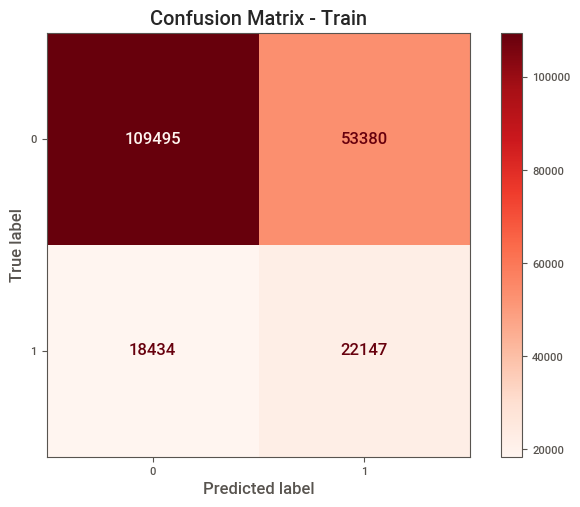

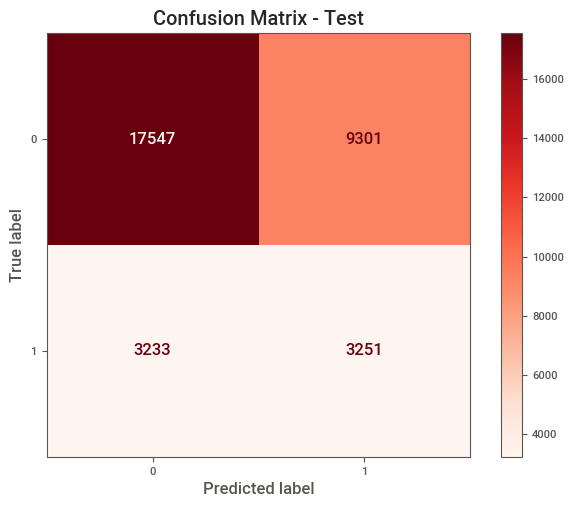

In [53]:
# Checking The Best Model Performance
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('--- Classification Report: Train ---')
print(classification_report(y_train, y_pred_train))
print()

print('--- Classification Report: Test ---')
print(classification_report(y_test, y_pred_test))
print()

print('--- Confusion Matrix ---')
disp_train = ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, cmap='Reds')
disp_train.ax_.set_title('Confusion Matrix - Train')
plt.show()

disp_test = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Reds')
disp_test.ax_.set_title('Confusion Matrix - Test')
plt.show()

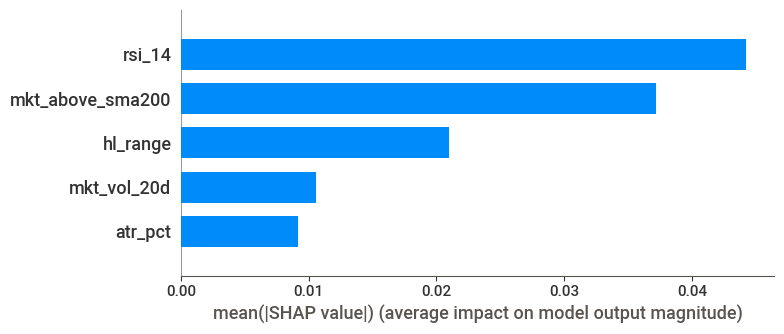

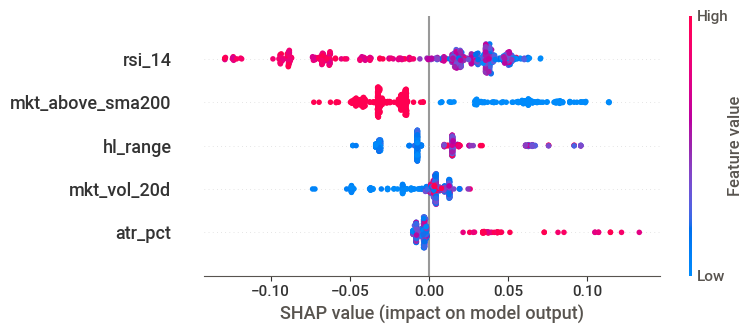

SHAP Importance Values:


,feature,mean_abs_shap
31,rsi_14,0.044222
55,mkt_above_sma200,0.037161
9,hl_range,0.020960
56,mkt_vol_20d,0.010562
29,atr_pct,0.009187
14,dist_ema_10,0.008541
46,vpt,0.007897
57,beta_60d,0.006413
21,crossover_ema_5_20,0.004636
6,body_size,0.003748


In [54]:
# Model Extraction
et_estimator = model[-1] 

# Sampling
X_val_df = X_train
sample_size = min(500, len(X_val_df))
X_sample = X_val_df.sample(n=sample_size, random_state=10)

# SHAP Explainer
explainer = shap.TreeExplainer(et_estimator)
shap_results = explainer.shap_values(X_sample)

if isinstance(shap_results, list):
    shap_values_to_plot = shap_results[1]
elif len(np.shape(shap_results)) == 3:
    shap_values_to_plot = shap_results[:, :, 1]
else:
    shap_values_to_plot = shap_results

# Visualization
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", max_display=5)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_sample, max_display=5)

# Importance Value
mean_shap_values = np.abs(shap_values_to_plot).mean(axis=0)

shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_shap_values
}).sort_values('mean_abs_shap', ascending=False)

print("SHAP Importance Values:")
display(shap_importance.head(50))

In [55]:
# Feature Experiment Design
feature_exp = [len(X_train.columns), 40, 30, 20, 15, 10]
model_exp = []

# Experiment
for n_fitur in feature_exp:
    top_features = shap_importance['feature'].head(n_fitur).tolist()
    X_train_subset = X_train[top_features]
    X_test_subset = X_test[top_features]
    
    model_eksperimen = ExtraTreesClassifier(
        n_estimators=500,
        class_weight='balanced',
        max_depth=6,
        max_leaf_nodes=31,
        random_state=42,
        n_jobs=-1
    )
    
    model_eksperimen.fit(X_train_subset, y_train)
    y_train_pred = model_eksperimen.predict(X_train_subset)
    y_test_pred = model_eksperimen.predict(X_test_subset)
    
    model_exp.append({
        'Jumlah Fitur': n_fitur,
        'Train Precision': precision_score(y_train, y_train_pred, zero_division=0),
        'Test Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Train Recall': recall_score(y_train, y_train_pred, zero_division=0),
        'Test Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'Train F1-Score': f1_score(y_train, y_train_pred, zero_division=0),
        'Test F1-Score': f1_score(y_test, y_test_pred, zero_division=0)
    })

df_exp = pd.DataFrame(model_exp)

print("\n--- Experiment Result ---")
display(df_exp.round(3))


--- Experiment Result ---


,Jumlah Fitur,Train Precision,Test Precision,Train Recall,Test Recall,Train F1-Score,Test F1-Score
0,65,0.293,0.261,0.554,0.515,0.383,0.347
1,40,0.291,0.262,0.564,0.518,0.384,0.348
2,30,0.290,0.263,0.574,0.535,0.385,0.353
3,20,0.288,0.262,0.572,0.526,0.383,0.350
4,15,0.288,0.261,0.536,0.500,0.374,0.343
5,10,0.286,0.260,0.549,0.505,0.376,0.343


# 8. Final Model

In [56]:
# The Best Features
n_features = 30
top_30_features = shap_importance['feature'].head(n_features).tolist()

# Split Target
X_train_final = X_train[top_30_features]
y_train_final = y_train

X_test_final = X_test[top_30_features]
y_test_final = y_test

In [57]:
# Model
final_model = ExtraTreesClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=6,
        max_leaf_nodes=30,
        random_state=42,
        n_jobs=-1)

# Model Training
final_model.fit(X_train_final, y_train_final)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight='balanced',
                     criterion='gini', max_depth=6, max_features='sqrt',
                     max_leaf_nodes=30, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=42, verbose=0, warm_start=False)

--- Classification Report: Train ---
              precision    recall  f1-score   support

           0       0.86      0.65      0.74    162875
           1       0.29      0.56      0.38     40581

    accuracy                           0.64    203456
   macro avg       0.57      0.61      0.56    203456
weighted avg       0.74      0.64      0.67    203456


--- Classification Report: Test ---
              precision    recall  f1-score   support

           0       0.85      0.64      0.73     26848
           1       0.26      0.53      0.35      6484

    accuracy                           0.62     33332
   macro avg       0.55      0.58      0.54     33332
weighted avg       0.73      0.62      0.65     33332


--- Confusion Matrix ---


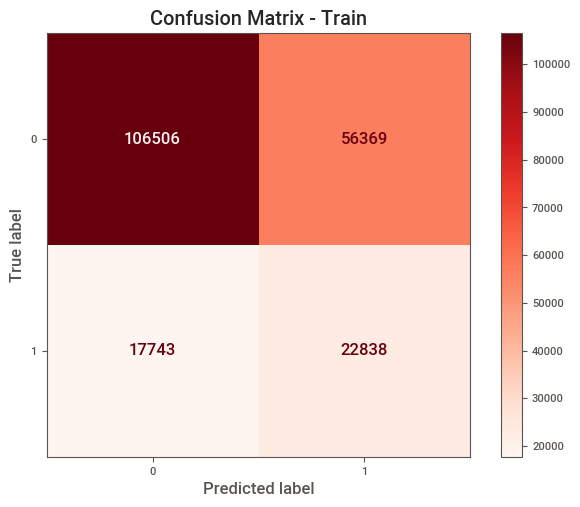

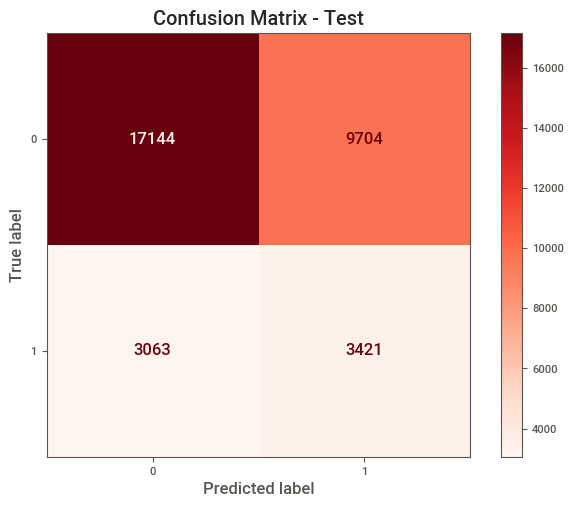

In [58]:
# Checking The Best Model Performance
y_pred_train_final = final_model.predict(X_train_final)
y_pred_test_final = final_model.predict(X_test_final)

print('--- Classification Report: Train ---')
print(classification_report(y_train_final, y_pred_train_final))
print()

print('--- Classification Report: Test ---')
print(classification_report(y_test_final, y_pred_test_final))
print()

print('--- Confusion Matrix ---')
disp_train_final = ConfusionMatrixDisplay.from_estimator(final_model, X_train_final, y_train_final, cmap='Reds')
disp_train_final.ax_.set_title('Confusion Matrix - Train')
plt.show()

disp_test_final = ConfusionMatrixDisplay.from_estimator(final_model, X_test_final, y_test_final, cmap='Reds')
disp_test_final.ax_.set_title('Confusion Matrix - Test')
plt.show()

AUC Score :  0.6122309630876481


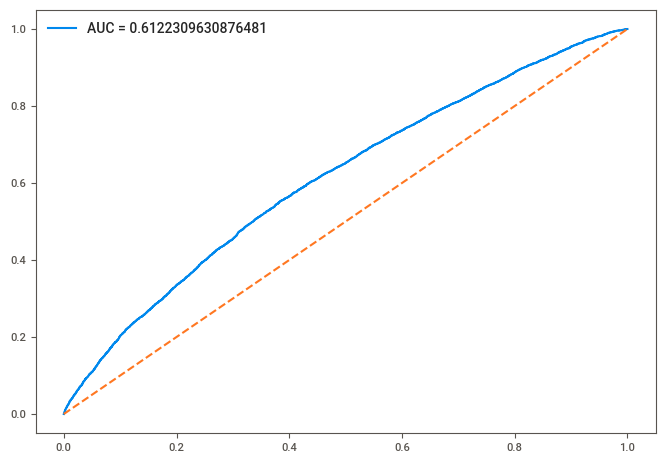

In [59]:
# Calculating AUC
y_pred = final_model.predict_proba(X_test_final)[:, 1]
fpr, tpr, _ = roc_curve(y_test_final, y_pred)
auc = roc_auc_score(y_test_final, y_pred)
print('AUC Score : ', auc)

# Visualizing ROC-AUC Curve
plt.figure(0).clf()
plt.plot(fpr, tpr, label='AUC = ' + str(auc))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=0)

# 9. Model Saving

In [60]:
# Saving Model
with open('C:/Users/DELL/Portfolio/Stock Pipeline/dags/models/final_model.pkl', 'wb') as a:
    dill.dump(final_model, a)